1. Condicionales 
2. Loops
3. Funciones de usuario 

# punto 1 del parcial 2_8

Geometría y Lógica de Regiones (Condicionales)
En Geometría Vectorial, una región rectangular puede definirse por sus límites en los ejes $X$ e $Y$. Escriba un programa que reciba las coordenadas de un punto $P(x, y)$ y determine si se encuentra:
1.	Dentro de un rectángulo definido por $x$ entre $[0, 5]$ e $y$ entre $[0, 10]$.
2.	En el borde del rectángulo.
3.	Fuera del rectángulo.
Extra: Si está fuera, indique si está a la "Derecha", "Izquierda", "Arriba" o "Abajo" del mismo usando condicionales anidados.


In [1]:
def determine_posición_respecto_rectangulo(P):
    if 0 < P[0] < 5 and 0 < P[1] < 10:
        print('el punto está dentro del rectángulo')
    elif ((0 <= P[0] <= 5) and (P[1] == 0)):
        print('el punto está en el borde inferior')
    elif ((0 <= P[0] <= 5) and (P[1] == 10)):
        print('el punto está en el borde superior del rectángulo')   
    elif ((P[0] == 0) and (0 <= P[1] <= 10)):
        print('el punto está en el borde izquierdo del rectángulo')        
    elif ((P[0] == 5) and (0 <= P[1] <= 10)):
        print('el punto está en el borde derecho del rectángulo') 
    elif (P[0] > 5):
        print('el punto está por fuera a la derecha del rectángulo')  
    elif (P[0] < 0):
        print('el punto está por fuera a la izquierda del rectángulo')  
    elif  (0<=P[0]<=5) and (P[1] > 10):
        print('el punto está por fuera y arriba del rectángulo')  
    elif  (0<=P[0]<=5) and (P[1] < 0):
        print('el punto está por fuera y abajo del rectángulo')             

In [5]:
determine_posición_respecto_rectangulo((2, 11))

el punto está por fuera y arriba del rectángulo


Este es un problema excelente para visualizar cómo la lógica de programación se traduce directamente en coordenadas espaciales. Vamos a segmentar la solución en la lógica de decisión y luego en las tres visualizaciones solicitadas.

---



## 1. Lógica del Problema (Python)

Utilizaremos condicionales para evaluar la posición del punto $P(x, y)$ respecto a los límites:
* **X:** $[0, 5]$
* **Y:** $[0, 10]$


In [15]:
def evaluar_punto(x, y):
    # Definición de límites
    x_min, x_max = 0, 5
    y_min, y_max = 0, 10
    
    # 1. Determinar si está dentro, en el borde o fuera
    if (x_min < x < x_max) and (y_min < y < y_max):
        resultado = "Dentro del rectángulo"
    elif (x_min <= x <= x_max) and (y_min <= y <= y_max):
        resultado = "En el borde del rectángulo"
    else:
        resultado = "Fuera del rectángulo"
        # Extra: Condicionales anidados para ubicación
        if x > x_max:
            posicion = "Derecha"
        elif x < x_min:
            posicion = "Izquierda"
        elif y > y_max:
            posicion = "Arriba"
        else:
            posicion = "Abajo"
        resultado += f" ({posicion})"
    
    return resultado

# Ejemplo de uso
px, py = 6,5
print(f"El punto ({px}, {py}) está: {evaluar_punto(px, py)}")


El punto (6, 5) está: Fuera del rectángulo (Derecha)


## 2. Representación con Matplotlib
Matplotlib es ideal para un control preciso sobre los ejes y la geometría básica.



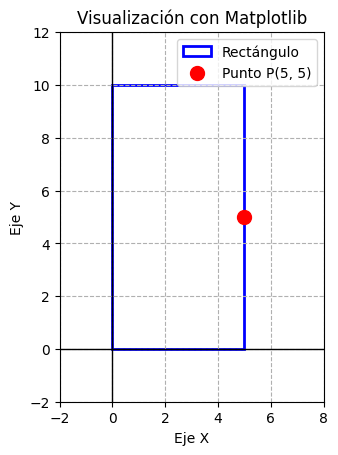

In [18]:
import matplotlib.pyplot as plt

def plot_matplotlib(px, py):
    fig, ax = plt.subplots()
    # Dibujar el rectángulo
    rect = plt.Rectangle((0, 0), 5, 10, linewidth=2, edgecolor='blue', facecolor='none', label='Rectángulo')
    ax.add_patch(rect)
    
    # Dibujar el punto
    ax.scatter(px, py, color='red', s=100, label=f'Punto P({px}, {py})')
    
    ax.set_xlim(-2, 8)
    ax.set_ylim(-2, 12)
    ax.axhline(0, color='black', lw=1)
    ax.axvline(0, color='black', lw=1)
    ax.grid(True, linestyle='--')
    ax.legend()
    plt.title("Visualización con Matplotlib")
    plt.xlabel("Eje X")
    plt.ylabel("Eje Y")
    plt.gca().set_aspect('equal', adjustable='box')
    plt.savefig(r"C:\Users\marco\Downloads\rectangulo_punto_matplotlib.png")
    plt.show()

plot_matplotlib(5,5)




## 3. Representación con Seaborn
Seaborn se enfoca más en datos estadísticos, pero podemos usarlo para una estética más limpia.


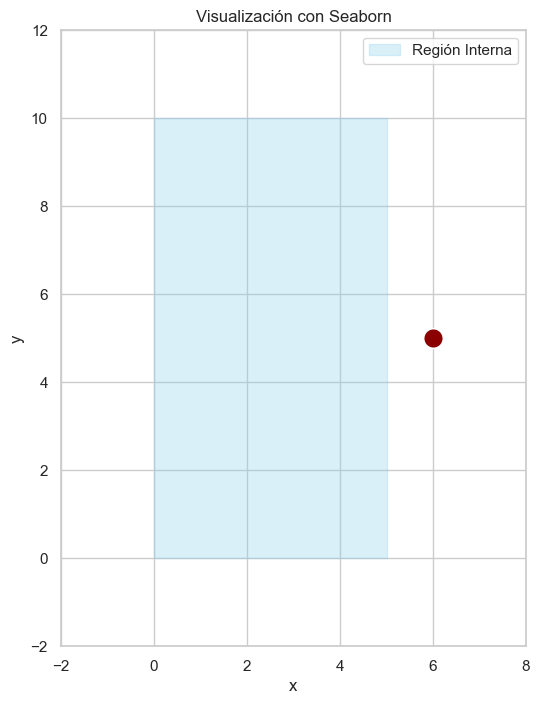

In [19]:
import seaborn as sns
import pandas as pd

def plot_seaborn(px, py):
    sns.set_theme(style="whitegrid")
    # Crear un "área" sombreada simulando el rectángulo
    plt.figure(figsize=(6, 8))
    plt.fill_between([0, 5], 0, 10, color='skyblue', alpha=0.3, label='Región Interna')
    
    # Dibujar el punto como un DataFrame para compatibilidad con seaborn
    df_punto = pd.DataFrame({'x': [px], 'y': [py]})
    sns.scatterplot(data=df_punto, x='x', y='y', color='darkred', s=200)
    
    plt.xlim(-2, 8)
    plt.ylim(-2, 12)
    plt.title("Visualización con Seaborn")
    plt.savefig(r"C:\Users\marco\Downloads\rectangulo_punto_seaborn.png")
    plt.show()

plot_seaborn(px, py)


## 4. Representación Interactiva con Plotly
Plotly nos permite pasar el ratón sobre el punto y ver sus coordenadas exactas.



In [20]:
import plotly.graph_objects as go

def plot_plotly(px, py):
    fig = go.Figure()

    # Agregar el rectángulo
    fig.add_shape(type="rect", x0=0, y0=0, x1=5, y1=10,
                  line=dict(color="RoyalBlue"), fillcolor="LightSkyBlue", opacity=0.5)

    # Agregar el punto
    fig.add_trace(go.Scatter(x=[px], y=[py], mode='markers+text',
                             marker=dict(size=15, color='Red'),
                             text=[f"P({px},{py})"], textposition="top center",
                             name="Punto P"))

    fig.update_layout(title="Región Geométrica Interactiva",
                      xaxis_range=[-2, 8], yaxis_range=[-2, 12],
                      width=500, height=600)
    fig.write_image(r"C:\Users\marco\Downloads\rectangulo_punto.png")
    fig.show()

plot_plotly(1, 5)


### Resumen Lógico
Para entender la ubicación, la computadora evalúa los límites como un sistema de inecuaciones:
* **Interior:** $0 < x < 5 \land 0 < y < 10$
* **Borde:** $(x \in [0,5] \land y \in \{0, 10\}) \lor (y \in [0,10] \land x \in \{0, 5\})$
* **Exterior:** Cualquier otro caso.

¿Te gustaría que profundizáramos en cómo manejar múltiples puntos a la vez usando arreglos de NumPy para hacer este proceso más eficiente?